# Exercise for Graph IV

In [42]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [43]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    number3: int
    number4: int
    operation2: str
    finalNumber: int
    finalNumber2: int

In [50]:
def adder_node(state: AgentState)-> AgentState:
    """This is simple function addition of 2 numbers"""
    state['finalNumber'] = state['number1'] + state['number2']
    return state

def subtractor_node(state: AgentState)-> AgentState:
    """This is simple function substract of 2 numbers"""
    state['finalNumber'] = state['number1'] - state['number2']
    
def decide_next_node(state: AgentState)-> AgentState:
    """This is simple function to decide the best choice"""
    if state['operation'] == "+":
        return "additional_node"
    elif state['operation'] == "-":
        return "subtraction_node"
    
def adder_node2(state: AgentState)-> AgentState:
    """This is simple function addition of 2 numbers"""
    state['finalNumber2'] = state['number3'] + state['number4']
    return state

def subtractor_node2(state: AgentState)-> AgentState:
    """This is simple function substract of 2 numbers"""
    state['finalNumber2'] = state['number3'] - state['number4']
    
def decide_next_node2(state: AgentState)-> AgentState:
    """This is simple function to decide the best choice"""
    if state['operation2'] == "+":
        return "additional_node2"
    elif state['operation2'] == "-":
        return "subtraction_node2"

In [51]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder_node)
graph.add_node("subtract_node", subtractor_node)
graph.add_node("router", lambda x:x)
graph.add_node("add_node2", adder_node2)
graph.add_node("subtract_node2", subtractor_node2)
graph.add_node("router2", lambda x:x)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        "additional_node": "add_node",
        "subtraction_node": "subtract_node"
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "additional_node2": "add_node2",
        "subtraction_node2": "subtract_node2"
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

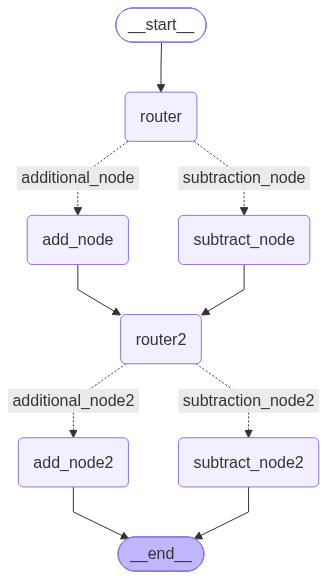

In [52]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))

In [53]:
initial_state = AgentState(number1 = 10, number2 = 5, operation="-", number3 = 7, number4 = 2, operation2 = "+", finalNumber=0, finalNumber2=0)
print(app.invoke(initial_state))

{'number1': 10, 'number2': 5, 'operation': '-', 'number3': 7, 'number4': 2, 'operation2': '+', 'finalNumber': 0, 'finalNumber2': 9}
